## PA005 - High Value Customer Identification (Rankers)

## 0.0 Planejamento da Soluçao (IOT)

### Input

🎯 Definição do Projeto – Programa Rankers

1️⃣ Problema de Negócio

Identificar e selecionar os clientes mais valiosos da base para compor o programa **Rankers**, priorizando aqueles com maior impacto no faturamento e maior potencial de retenção.

O objetivo é concentrar esforços estratégicos nos clientes que mais contribuem para o crescimento sustentável do negócio.

---

2️⃣ Conjunto de Dados

A análise foi realizada com base em:

- 📊 Dados de vendas de um e-commerce online  
- 📆 Período analisado: 1 ano  

Esses dados permitem avaliar comportamento de compra, frequência, recência e geração de receita.

### Output

1️⃣ Indicação dos Participantes

Entrega de uma lista objetiva contendo:

- Identificação do cliente  
- Status: **É Ranker? (Sim/Não)**  

Essa lista será a base oficial do programa.

---

2️⃣ Relatório Executivo

O relatório deverá responder às principais perguntas de negócio:

- Quem são as pessoas elegíveis ao programa?
- Quantos clientes farão parte do grupo?
- Quais são as principais características desses clientes?
- Qual a porcentagem de contribuição no faturamento total?
- Qual a expectativa de faturamento para os próximos meses?
- Quais são as condições para elegibilidade?
- Quais são as condições para remoção do programa?
- Qual a garantia de que o programa é superior ao restante da base?
- Quais ações de marketing podem aumentar o faturamento?

### Tasks

1️⃣ Quem são as pessoas elegíveis ao programa?

Definição de Elegibilidade

**📈 Faturamento**
- Alto ticket médio  
- Alto Lifetime Value (LTV)  
- Baixa recência (compras recentes)  
- Alto basket size  
- Baixa probabilidade de churn  
- Alta propensão de compra  

**💰 Custo**
- Baixa taxa de devolução  

**⭐ Experiência de Compra**
- Alta média de avaliação  

---

2️⃣ Quantos clientes farão parte do grupo?

- Número total de clientes elegíveis  
- Percentual que representam dentro da base  

---

3️⃣ Quais as principais características desses clientes?

**👤 Perfil Demográfico**
- Idade  
- Localização  
- Gênero  

**🛒 Perfil Comportamental**
- Atributos identificados na clusterização  

---

4️⃣ Qual a porcentagem de contribuição no faturamento?

- Faturamento total do ano  
- Faturamento gerado pelo grupo Ranker  
- Participação percentual do grupo na receita  

---

5️⃣ Qual a expectativa de faturamento futuro?

- Análise de LTV do grupo Ranker  
- Análise de Cohort para projeção de receita  

---

6️⃣ Condições para elegibilidade

- Definição de periodicidade de avaliação (mensal, bimestral, trimestral)  
- Similaridade com o perfil médio do grupo Ranker  

---

7️⃣ Condições para remoção

- Reavaliação periódica  
- Desvio significativo dos indicadores de valor  

---

8️⃣ Garantia de superioridade do programa

- Teste A/B comparando Rankers vs. base geral  
- Testes estatísticos de validação de impacto  

---

9️⃣ Ações estratégicas de marketing

- Relacionamento personalizado (ex: visita à empresa)  
- Benefícios exclusivos  
- Descontos estratégicos  

# 0.0 Imports

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import inflection

import umap.umap_ as umap

from kneed import KneeLocator
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import SilhouetteVisualizer
from matplotlib import pyplot as plt

## 0.1 Helper Functions

In [97]:
def vscode_settings():
    plt.style.use('bmh')
    
    plt.rcParams['figure.figsize'] = [25, 12]
    plt.rcParams['font.size'] = 14
    plt.rcParams['font.family'] = 'DejaVu Sans'
    
    pd.options.display.max_columns = None
    pd.options.display.max_rows = None
    pd.set_option('display.expand_frame_repr', False)
    
    sns.set_palette("Set2")

vscode_settings()       

In [98]:
def plot_settings():
    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd

    # Base limpa
    plt.style.use('seaborn-v0_8-whitegrid')
    
    # Tamanho equilibrado
    plt.rcParams['figure.figsize'] = (14, 8)
    plt.rcParams['figure.dpi'] = 120
    
    # Fonte segura
    plt.rcParams['font.family'] = 'DejaVu Sans'
    plt.rcParams['font.size'] = 12
    
    # Grid mais leve
    plt.rcParams['grid.alpha'] = 0.3
    plt.rcParams['grid.linestyle'] = '--'
    
    # Remove bordas desnecessárias
    plt.rcParams['axes.spines.top'] = False
    plt.rcParams['axes.spines.right'] = False
    
    # Paleta mais profissional
    sns.set_palette("colorblind")
    
    # Pandas display
    pd.options.display.max_columns = None
    pd.options.display.max_rows = 200
    pd.set_option('display.expand_frame_repr', False)

plot_settings()

## 0.2 Load Dataset

In [99]:
df_raw = (
    pd.read_csv(
        '../data/Ecommerce.csv',
        encoding='latin1'
    )
    .loc[:, lambda df: ~df.columns.str.contains('^Unnamed')]
)

In [100]:
df_raw.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,29-Nov-16,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,29-Nov-16,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,29-Nov-16,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,29-Nov-16,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,29-Nov-16,3.39,17850.0,United Kingdom


# 1.0 Data Description

In [101]:
df1 = df_raw

## 1.1 Rename columns

In [102]:
df1.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [103]:
cols_old = df1.columns

snakecase = lambda x: inflection.underscore(x)
cols_new = list(map(snakecase, cols_old))

df1.columns = cols_new
df1.sample()

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
61643,541435,21232,STRAWBERRY CERAMIC TRINKET BOX,12,16-Jan-17,1.25,13898.0,United Kingdom


## 1.2 Data Dimensions

In [104]:
df1.shape

(541909, 8)

## 1.3 Data types

In [105]:
df1.dtypes

invoice_no          str
stock_code          str
description         str
quantity          int64
invoice_date        str
unit_price      float64
customer_id     float64
country             str
dtype: object

## 1.4 Check NA

In [106]:
df1.isna().sum()

invoice_no           0
stock_code           0
description       1454
quantity             0
invoice_date         0
unit_price           0
customer_id     135080
country              0
dtype: int64

## 1.5 Replace NA

In [107]:
# remove NA - Ciclo 1

df1 = df1.dropna(subset=['description', 'customer_id'])
print('Removed data: {:.2%}'.format( 1-(df1.shape[0] / df_raw.shape[0])))

Removed data: 24.93%


In [108]:
df1.isna().sum()

invoice_no      0
stock_code      0
description     0
quantity        0
invoice_date    0
unit_price      0
customer_id     0
country         0
dtype: int64

## 1.6 Change dtypes

In [109]:
df1.dtypes

invoice_no          str
stock_code          str
description         str
quantity          int64
invoice_date        str
unit_price      float64
customer_id     float64
country             str
dtype: object

In [110]:
# invoice date

df1['invoice_date'] = pd.to_datetime(df1['invoice_date'], format='%d-%b-%y')

#customer_id

df1['customer_id']  = df1['customer_id'].astype(int)

In [111]:
df1.dtypes

invoice_no                 str
stock_code                 str
description                str
quantity                 int64
invoice_date    datetime64[us]
unit_price             float64
customer_id              int64
country                    str
dtype: object

## 1.7 Descriptive Statistics

# 2.0 Feature Engineering

In [112]:
df2 = df1.copy()

## 2.1 Feature Creation

In [113]:
df2.head()

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2016-11-29,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2016-11-29,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2016-11-29,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2016-11-29,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2016-11-29,3.39,17850,United Kingdom


In [114]:
# data reference
df_ref = df2.drop(['invoice_no', 'stock_code', 'description', ''
                    'quantity', 'invoice_date', 'unit_price', 'country'], axis=1).drop_duplicates().reset_index(drop=True)
df_ref.head(10)

,customer_id
0,17850
1,13047
2,12583
3,13748
4,15100
5,15291
6,14688
7,17809
8,15311
9,14527


In [115]:
df2.head()

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2016-11-29,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2016-11-29,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2016-11-29,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2016-11-29,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2016-11-29,3.39,17850,United Kingdom


In [116]:
# Gross Revenue quantity * price = faturamento
df2['gross_revenue'] = df2['quantity'] * df2['unit_price']

# Monetary
df_monetary = df2[['customer_id','gross_revenue']].groupby('customer_id').sum().reset_index()
df_ref = pd.merge(df_ref, df_monetary, on='customer_id', how='left')

# Recency - Last day purchase
df_recency = df2[['customer_id', 'invoice_date']].groupby('customer_id').max().reset_index()
df_recency['recency_days'] = (df2['invoice_date'].max() - df_recency['invoice_date']).dt.days
df_recency = df_recency[['customer_id', 'recency_days']].copy()
df_ref = pd.merge(df_ref, df_recency, on='customer_id', how='left')

# Frequency - Frequencia de Carrinhos / Compras finalizadas independente da quantidade de produtos em cada
df_freq = (df1.groupby('customer_id')['invoice_no'].nunique().reset_index().rename(columns={'invoice_no': 'frequency'}))
df_ref = pd.merge(df_ref, df_freq, on='customer_id', how='left')

# AVG ticket
df_avg_ticket = df2[['customer_id','gross_revenue']].groupby('customer_id').mean().reset_index().rename(columns={'gross_revenue':'avg_ticket'})
df_ref = pd.merge(df_ref, df_avg_ticket, on='customer_id', how='left')


In [117]:
df_ref.isna().sum()

customer_id      0
gross_revenue    0
recency_days     0
frequency        0
avg_ticket       0
dtype: int64

In [118]:
df_ref.head()

,customer_id,gross_revenue,recency_days,frequency,avg_ticket
0,17850,5288.63,302,35,16.950737
1,13047,3079.10,31,18,15.709694
2,12583,7187.34,2,18,28.634821
3,13748,948.25,95,5,33.866071
4,15100,635.10,330,6,105.850000


# 3.0 Feature Filtering

In [119]:
df3 = df_ref.copy()

# 4.0 EDA

In [120]:
df4 = df3.copy()

# 5.0 Data Preparation

In [121]:
df5 = df4.copy()

# 6.0 Feature Selection

In [122]:
df6 = df5.copy()

In [123]:
df6.head()

,customer_id,gross_revenue,recency_days,frequency,avg_ticket
0,17850,5288.63,302,35,16.950737
1,13047,3079.10,31,18,15.709694
2,12583,7187.34,2,18,28.634821
3,13748,948.25,95,5,33.866071
4,15100,635.10,330,6,105.850000


# 7.0 Hyperparameter Fine-Tunning

In [124]:
df7 = df6.copy()

In [125]:
X = df7.drop(columns=['customer_id'])

In [126]:
clusters = [2,3,4,5,6,7,8,9,10,11]

## 7.1 Within-Cluster Sum of Square (WSS)

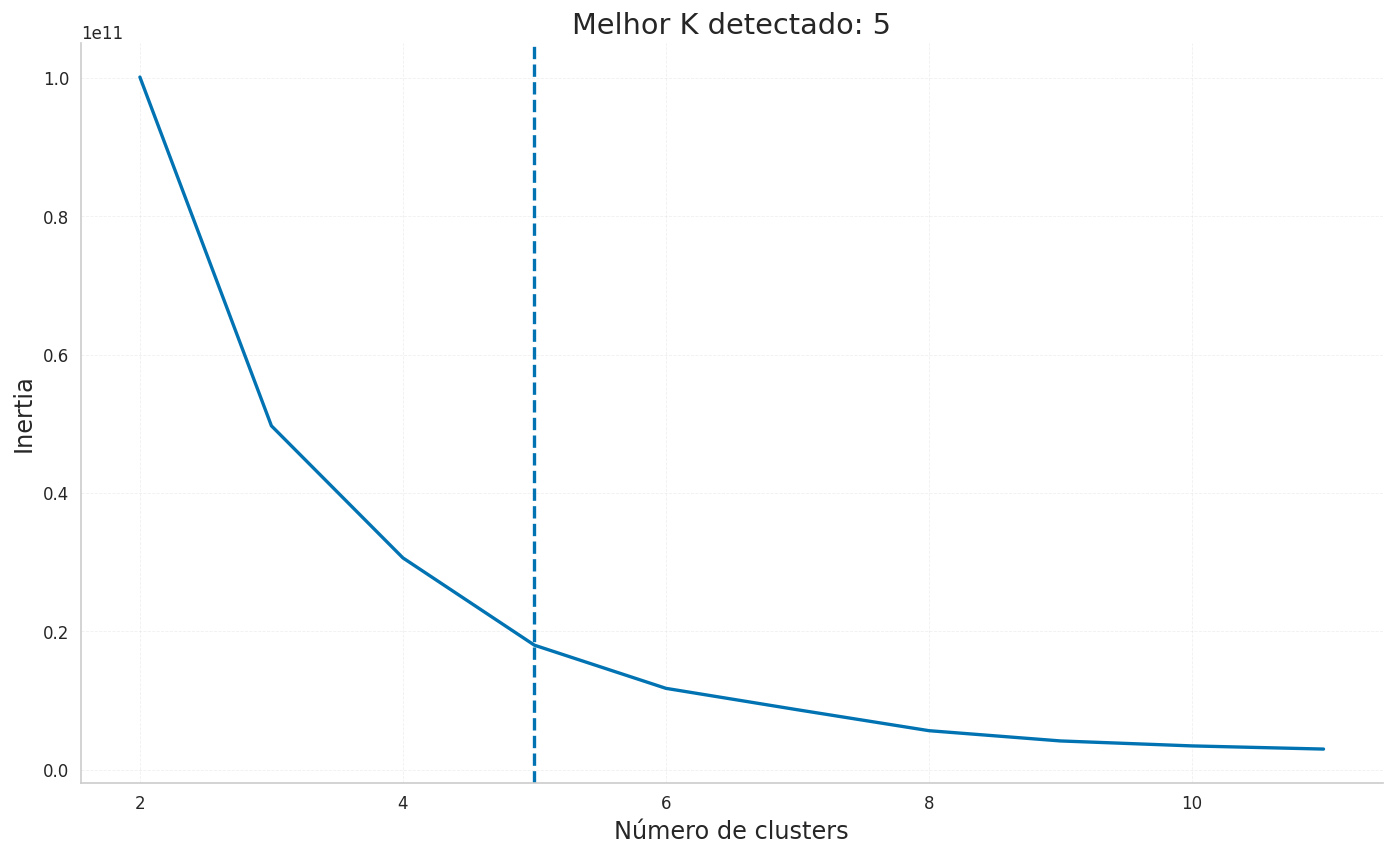

In [127]:
inertia = []

for k in clusters:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X)
    inertia.append(model.inertia_)

# Detectando o cotovelo
knee = KneeLocator(clusters, inertia, curve="convex", direction="decreasing")
best_k = knee.knee

# Plot
plt.plot(clusters, inertia)
plt.axvline(best_k, linestyle="--")
plt.xlabel("Número de clusters")
plt.ylabel("Inertia")
plt.title(f"Melhor K detectado: {best_k}")
plt.show()

## 7.2 Silhouette Score

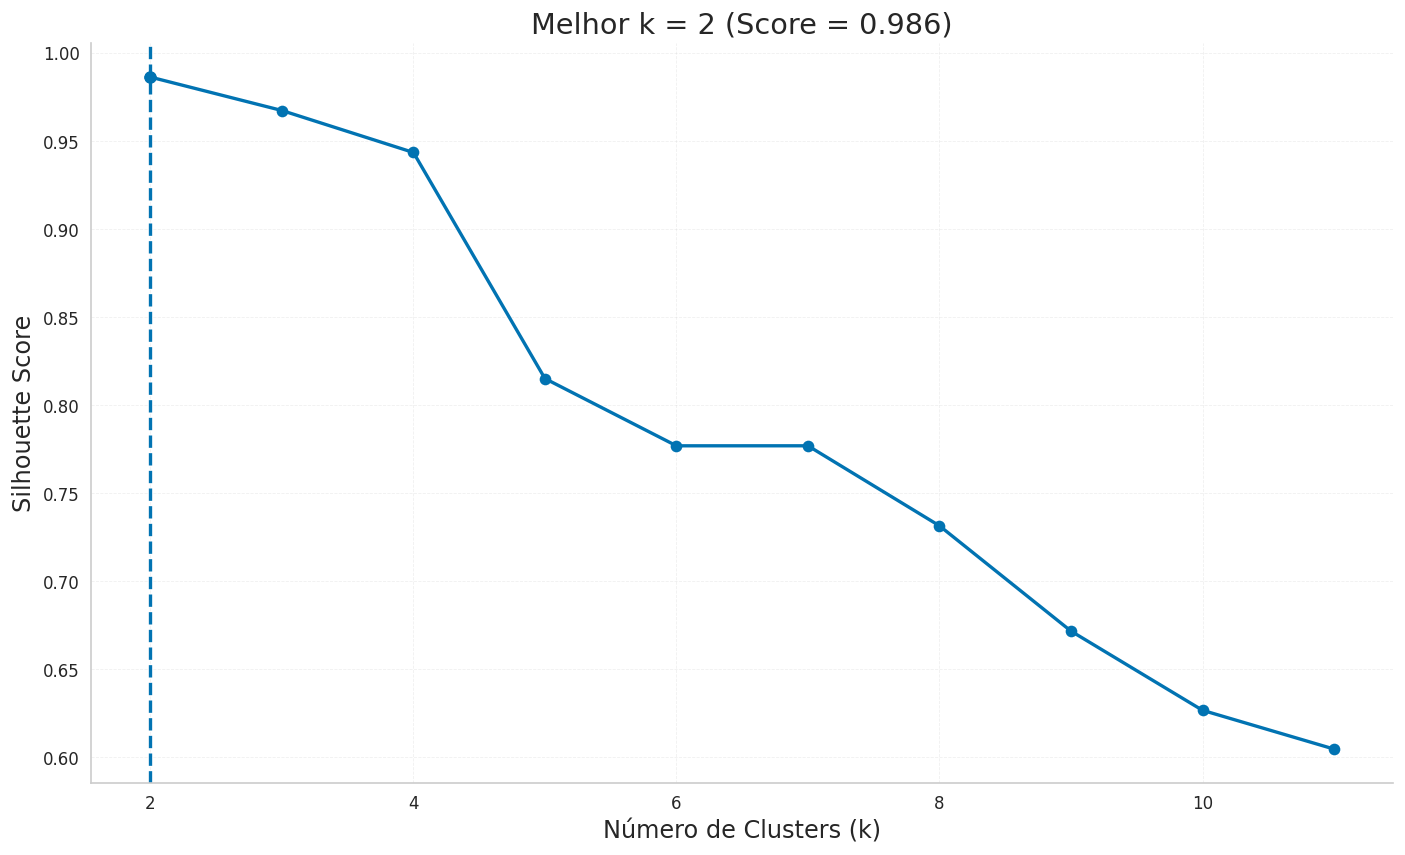

In [128]:
sil_scores = []

for k in clusters:
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(X)
    sil_scores.append(silhouette_score(X, labels))

# Melhor k (maior silhouette)
best_index = np.argmax(sil_scores)
best_k = list(clusters)[best_index]
best_score = sil_scores[best_index]

# Plot
plt.plot(clusters, sil_scores, marker='o')
plt.axvline(best_k, linestyle='--')
plt.scatter(best_k, best_score)
plt.xlabel("Número de Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title(f"Melhor k = {best_k} (Score = {best_score:.3f})")
plt.show()

### 7.2.1 Silhouette Analysis

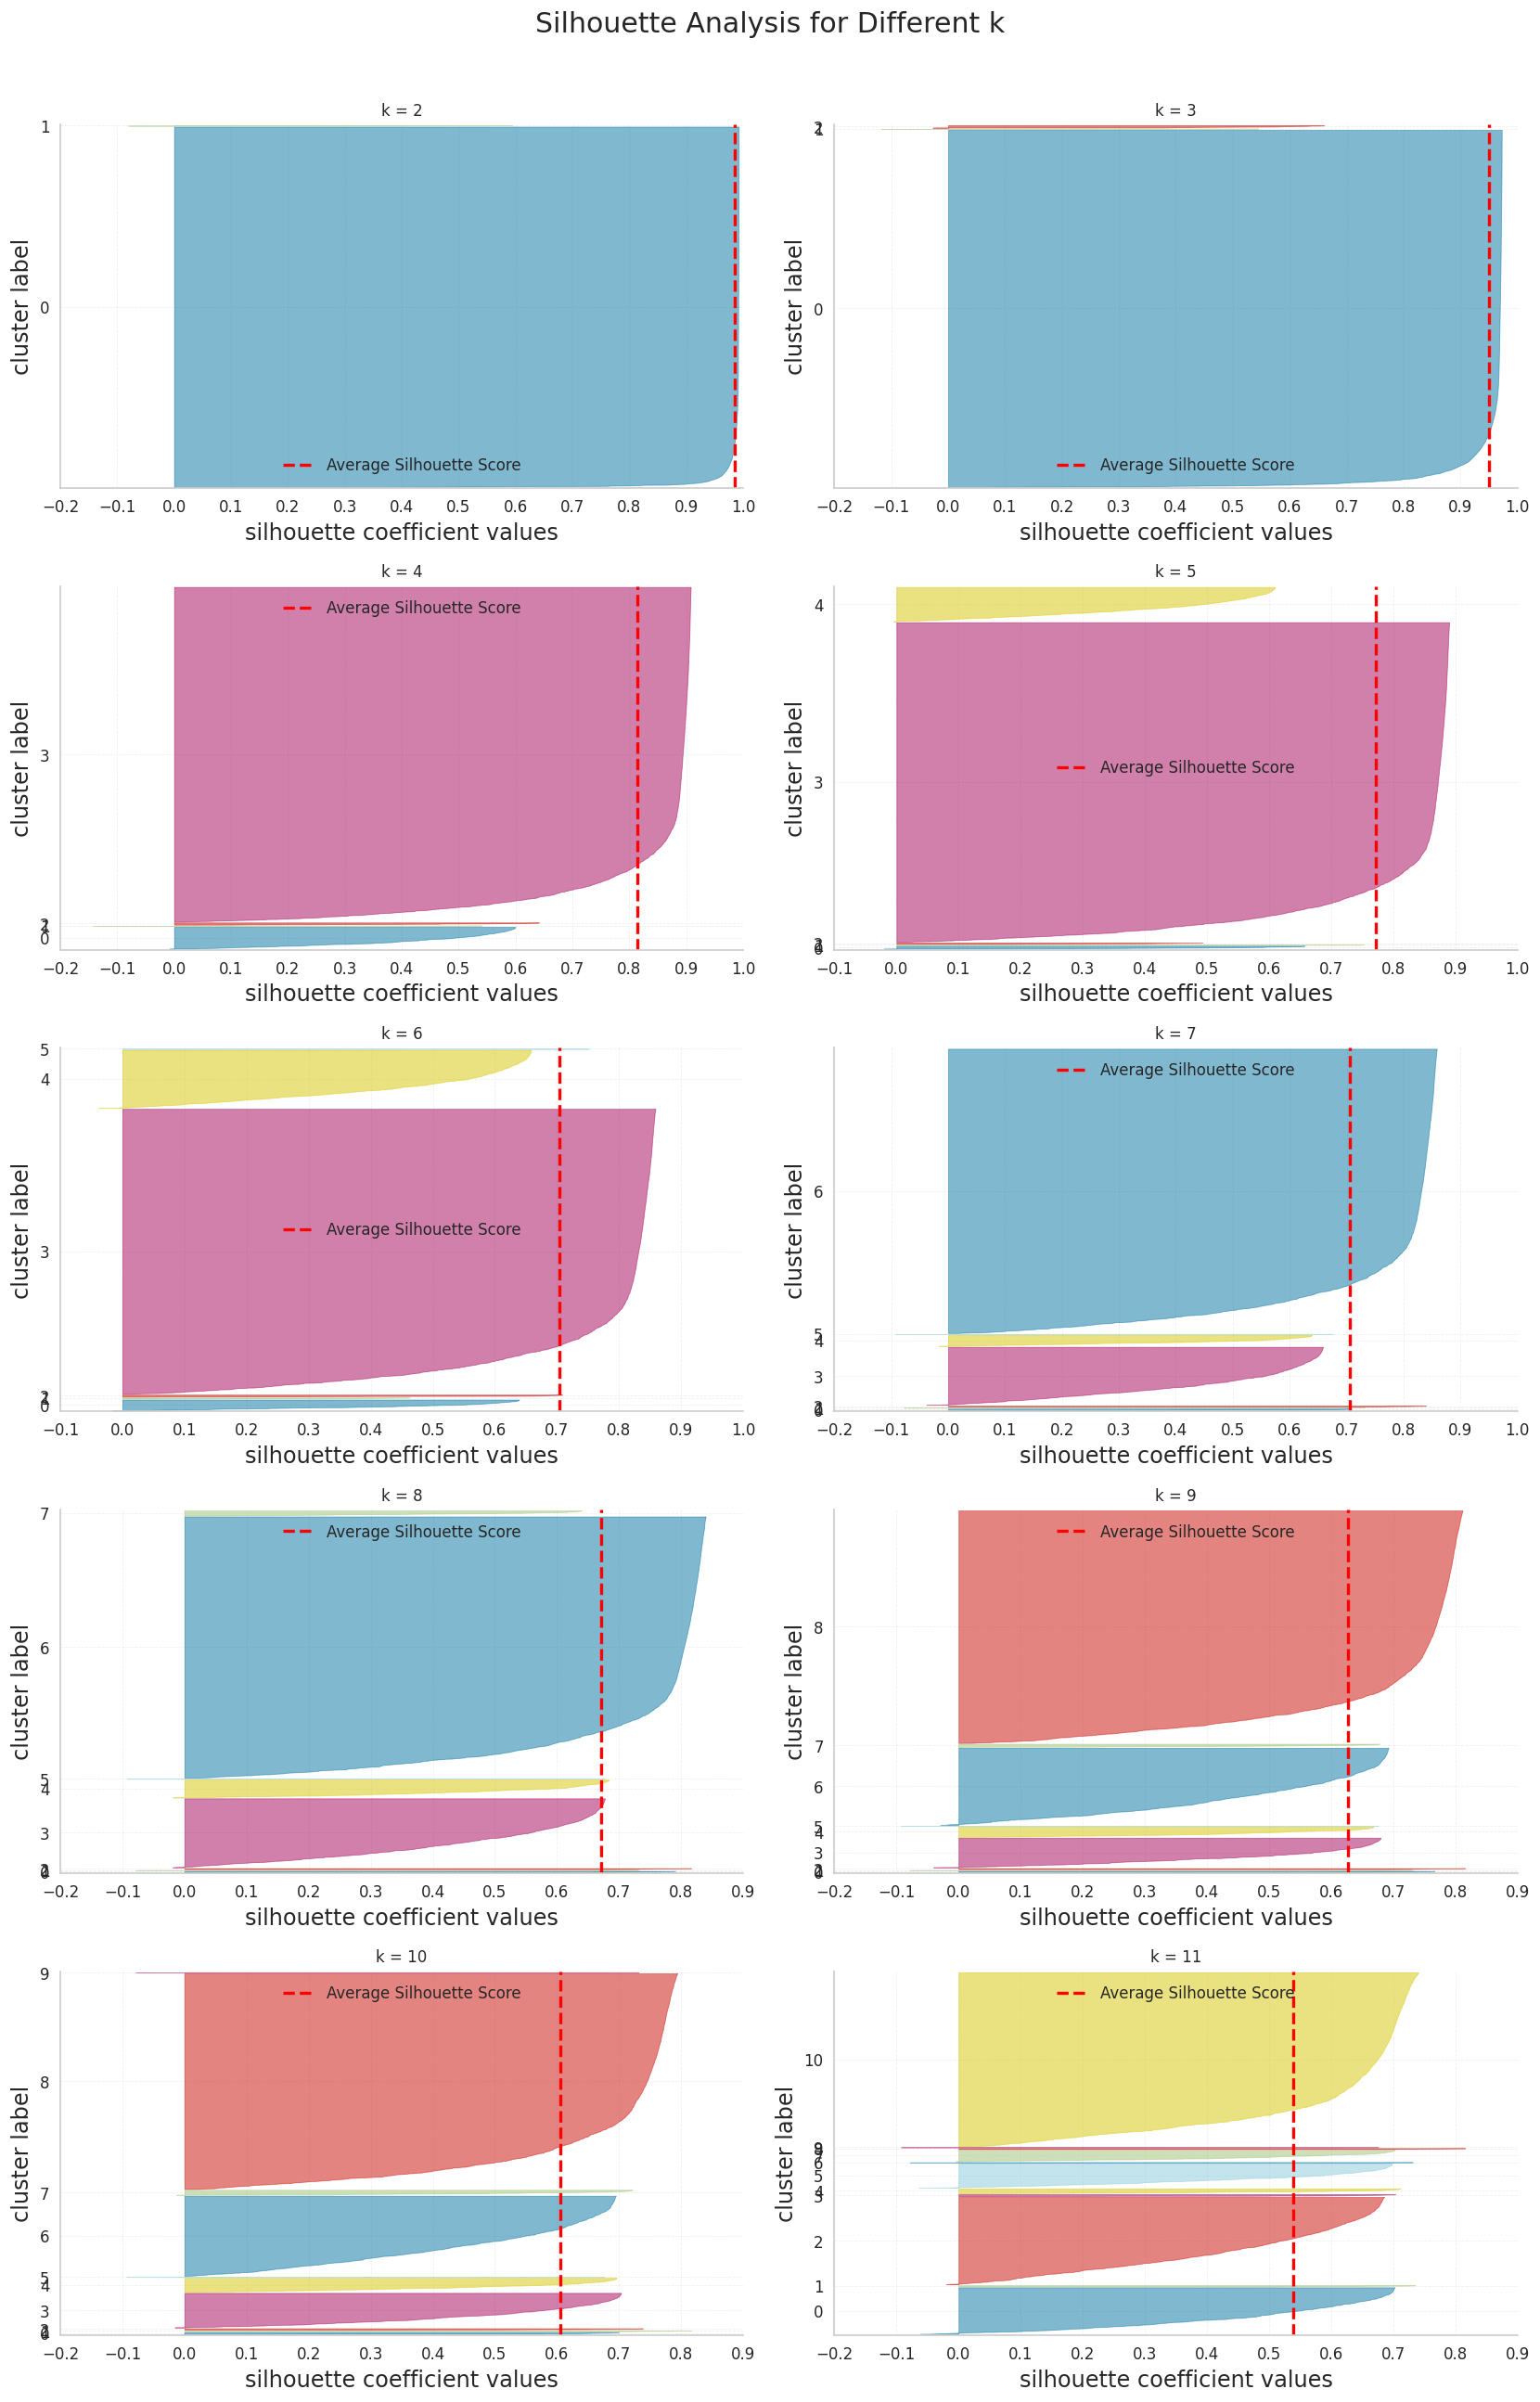

In [141]:
clusters = [2,3,4,5,6,7,8,9,10,11]

fig, ax = plt.subplots(5, 2, figsize=(14, 22))

for i, k in enumerate(clusters):
    
    km = KMeans(
        n_clusters=k,
        init='random',
        n_init=10,
        max_iter=100,
        random_state=42
    )
    
    row = i // 2
    col = i % 2
    
    visualizer = SilhouetteVisualizer(
        km,
        colors='yellowbrick',
        ax=ax[row][col],
        force_model=True
    )
    
    visualizer.fit(X)
    visualizer.finalize()
    
    ax[row][col].set_title(f"k = {k}", fontsize=10)

fig.suptitle("Silhouette Analysis for Different k", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

# 8.0 Model Training

## 8.1 KMeans

In [173]:
k = 6
model = KMeans(init='random', n_clusters=k, n_init=10, max_iter=300)

model.fit(X)

labels = model.labels_

## 8.2 Cluster Validation

In [174]:
# WSS

print('WSS: {}'.format(model.inertia_))

# Silhouette
print('Silhouette: {}'.format(silhouette_score(X, labels, metric='euclidean')))

WSS: 20043339533.061302
Silhouette: 0.7040495676085154


# 9.0 Cluster Analysis

In [175]:
df6.head()

,customer_id,gross_revenue,recency_days,frequency,avg_ticket
0,17850,5288.63,302,35,16.950737
1,13047,3079.10,31,18,15.709694
2,12583,7187.34,2,18,28.634821
3,13748,948.25,95,5,33.866071
4,15100,635.10,330,6,105.850000


In [176]:
df9 = df6.copy()
df9['cluster'] = labels
df9.head()

,customer_id,gross_revenue,recency_days,frequency,avg_ticket,cluster
0,17850,5288.63,302,35,16.950737,5
1,13047,3079.10,31,18,15.709694,5
2,12583,7187.34,2,18,28.634821,4
3,13748,948.25,95,5,33.866071,2
4,15100,635.10,330,6,105.850000,2


## 9.1 Visualization - Knife

/home/pollon/.pyenv/versions/3.11.8/envs/pa005_rankers/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


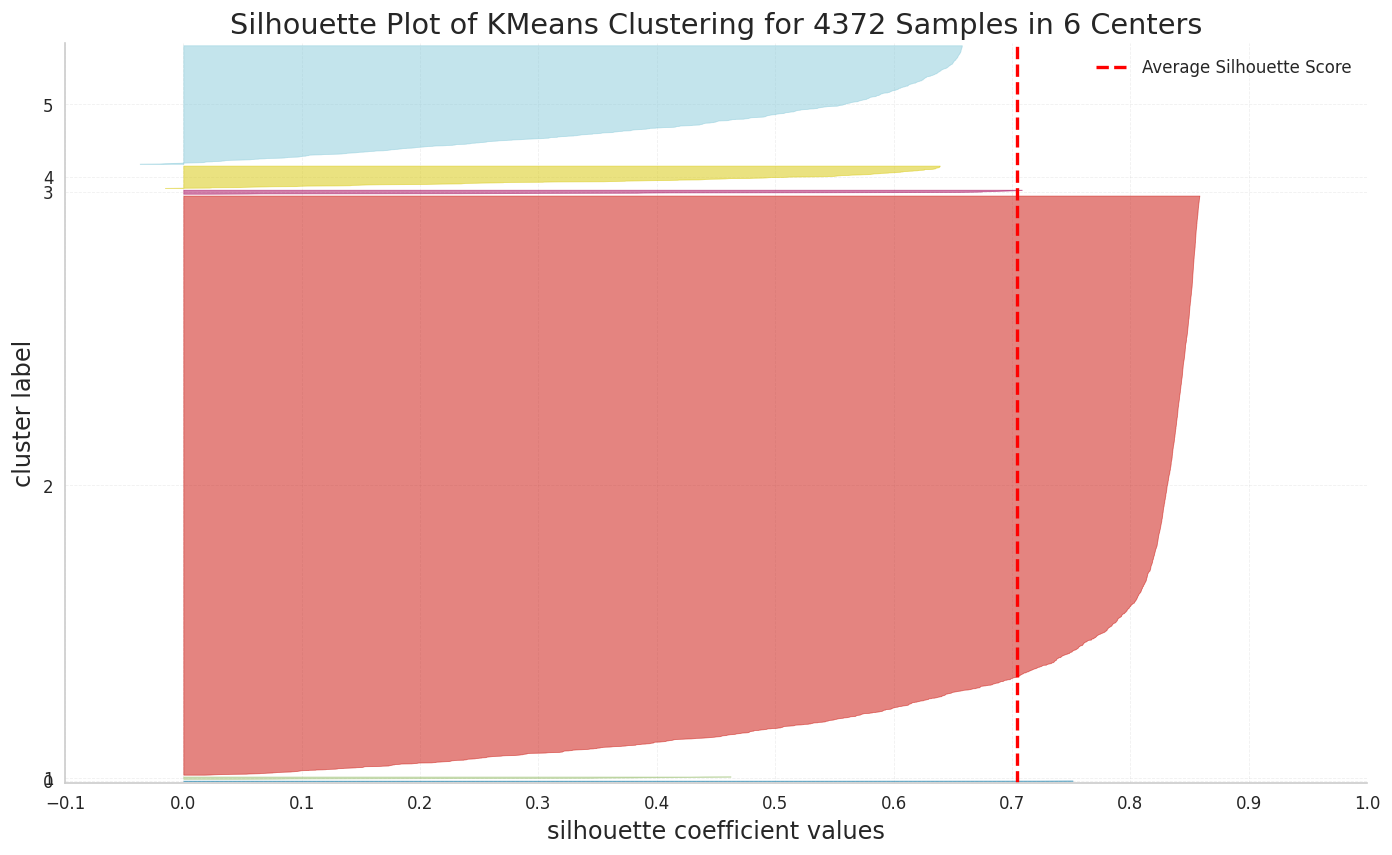

In [177]:
visualizer = SilhouetteVisualizer(model, colors='yellowbrick', force_model=True)
visualizer.fit(X)
visualizer.finalize()

## 9.1.2 Visualization - 2d plot

In [178]:
df9.head()

,customer_id,gross_revenue,recency_days,frequency,avg_ticket,cluster
0,17850,5288.63,302,35,16.950737,5
1,13047,3079.10,31,18,15.709694,5
2,12583,7187.34,2,18,28.634821,4
3,13748,948.25,95,5,33.866071,2
4,15100,635.10,330,6,105.850000,2


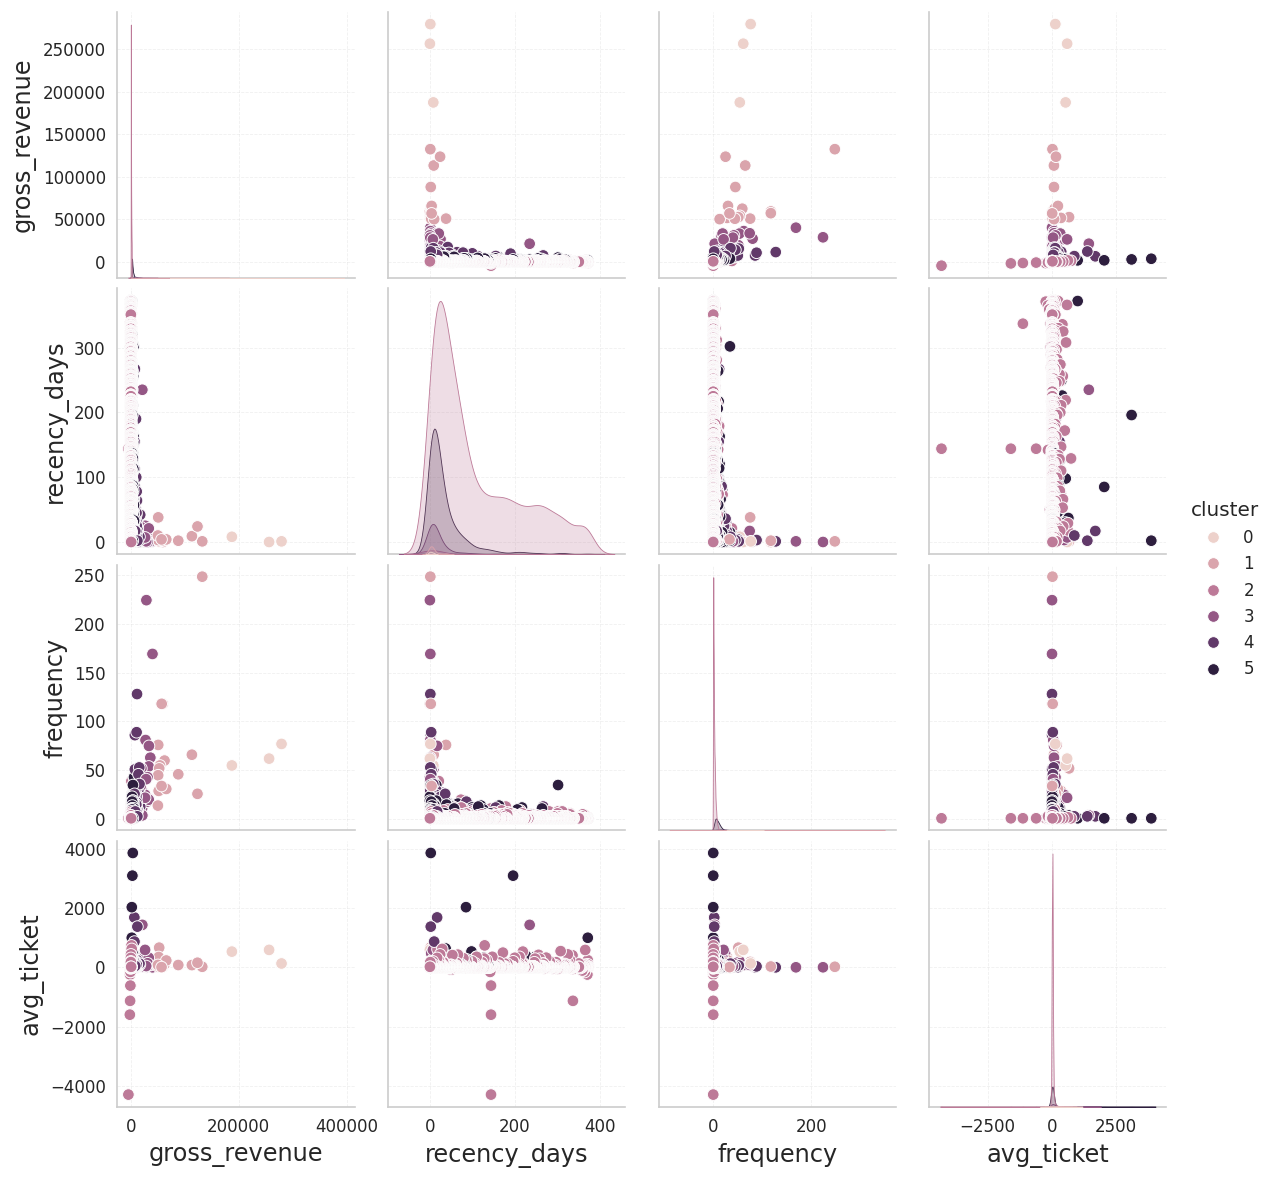

In [179]:
df_viz = df9.drop(columns='customer_id')
sns.pairplot(df_viz, hue='cluster');

## 9.1.3 Visualization - UMAP

In [180]:
X.head()

,gross_revenue,recency_days,frequency,avg_ticket
0,5288.63,302,35,16.950737
1,3079.10,31,18,15.709694
2,7187.34,2,18,28.634821
3,948.25,95,5,33.866071
4,635.10,330,6,105.850000


/home/pollon/.pyenv/versions/3.11.8/envs/pa005_rankers/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


<Axes: xlabel='embedding_x', ylabel='embedding_y'>

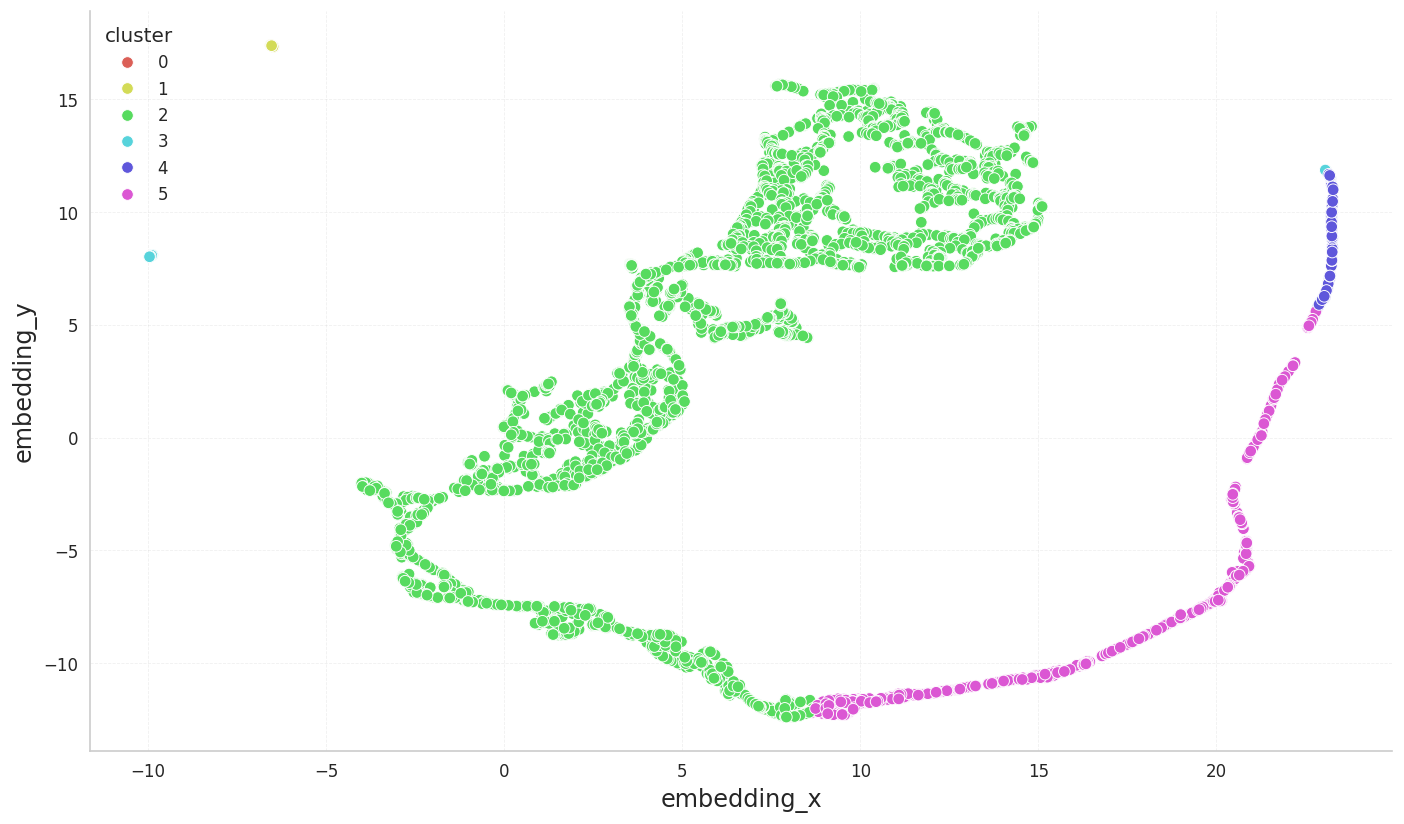

In [184]:
reducer = umap.UMAP(n_neighbors=7, random_state=42)
embedding = reducer.fit_transform(X)

# embedding
df_viz['embedding_x'] = embedding[:, 0]
df_viz['embedding_y'] = embedding[:, 1]

# plor
sns.scatterplot(x='embedding_x', y='embedding_y', hue='cluster', 
                    palette=sns.color_palette('hls', n_colors=len(df_viz['cluster'].unique())), data=df_viz)

## 9.2 Cluster Profile

In [196]:
#### Implementar PCA para decidir pesos das features/Substituir ticket médio por LTV

In [185]:
df9.head()

,customer_id,gross_revenue,recency_days,frequency,avg_ticket,cluster
0,17850,5288.63,302,35,16.950737,5
1,13047,3079.10,31,18,15.709694,5
2,12583,7187.34,2,18,28.634821,4
3,13748,948.25,95,5,33.866071,2
4,15100,635.10,330,6,105.850000,2


In [197]:
df_cluster = (
    df9
        .groupby('cluster')
        .agg(
            customer_count      = ('customer_id', 'nunique'),
            total_gross_revenue = ('gross_revenue', 'sum'),
            avg_gross_revenue   = ('gross_revenue', 'mean'),
            avg_recency_days    = ('recency_days', 'mean'),
            avg_frequency       = ('frequency', 'mean'),
        )
        .reset_index()
)

df_cluster['perc_revenue'] = (
    100 * df_cluster['total_gross_revenue']
    / df_cluster['total_gross_revenue'].sum()
)

df_cluster_display = df_cluster.round(2)

df_rank = df_cluster_display.copy()

# Normalização
df_rank['norm_ticket'] = (
    (df_rank['avg_gross_revenue'] - df_rank['avg_gross_revenue'].min()) /
    (df_rank['avg_gross_revenue'].max() - df_rank['avg_gross_revenue'].min())
)

df_rank['norm_freq'] = (
    (df_rank['avg_frequency'] - df_rank['avg_frequency'].min()) /
    (df_rank['avg_frequency'].max() - df_rank['avg_frequency'].min())
)

df_rank['norm_recency'] = 1 - (
    (df_rank['avg_recency_days'] - df_rank['avg_recency_days'].min()) /
    (df_rank['avg_recency_days'].max() - df_rank['avg_recency_days'].min())
)

# Penalização por tamanho (clusters muito grandes perdem ponto)
df_rank['size_penalty'] = (
    (df_rank['customer_count'] - df_rank['customer_count'].min()) /
    (df_rank['customer_count'].max() - df_rank['customer_count'].min())
)

# Score final
df_rank['score'] = (
    df_rank['norm_ticket'] * 0.5 +
    df_rank['norm_freq'] * 0.25 +
    df_rank['norm_recency'] * 0.25 -
    df_rank['size_penalty'] * 0.2
)

df_rank = df_rank.sort_values('score', ascending=False).reset_index(drop=True)
df_rank

,cluster,customer_count,total_gross_revenue,avg_gross_revenue,avg_recency_days,avg_frequency,perc_revenue,norm_ticket,norm_freq,norm_recency,size_penalty,score
0,0,3,723409.68,241136.56,3.00,64.67,8.72,1.000000,0.950845,1.000000,0.000000,0.987711
1,1,15,1071352.74,71423.52,7.40,67.87,12.91,0.294397,1.000000,0.957733,0.003450,0.635942
2,3,25,671443.50,26857.74,15.16,47.76,8.09,0.109110,0.691091,0.883189,0.006325,0.446860
3,4,135,1319411.05,9773.42,19.47,22.41,15.90,0.038080,0.301690,0.841787,0.037953,0.297318
4,5,713,2375538.25,3331.75,34.27,9.99,28.62,0.011298,0.110906,0.699616,0.204140,0.167451
5,2,3481,2138910.59,614.45,107.10,2.77,25.77,0.000000,0.000000,0.000000,1.000000,-0.200000


In [198]:
from IPython.display import Markdown, display

medals = ["🥇 Rankers", "🥈 Fortes Candidatos", "🥉 Consideráveis"]

texto = "### 🏆 Análise de Candidatos a Rankers\n\n"

for i in range(min(3, len(df_rank))):
    row = df_rank.iloc[i]
    
    texto += f"""
{medals[i]} **Cluster {int(row['cluster'])}**

🔥 **Recência média:** {row['avg_recency_days']:.0f} dias  
🔁 **Frequência média:** {row['avg_frequency']:.0f} compras  
💰 **Ticket médio:** {row['avg_gross_revenue']:,.0f}  
👥 **Clientes:** {int(row['customer_count'])}  
📊 **Score:** {row['score']:.3f}

---

"""

display(Markdown(texto))

### 🏆 Análise de Candidatos a Rankers


🥇 Rankers **Cluster 0**

🔥 **Recência média:** 3 dias  
🔁 **Frequência média:** 65 compras  
💰 **Ticket médio:** 241,137  
👥 **Clientes:** 3  
📊 **Score:** 0.988

---


🥈 Fortes Candidatos **Cluster 1**

🔥 **Recência média:** 7 dias  
🔁 **Frequência média:** 68 compras  
💰 **Ticket médio:** 71,424  
👥 **Clientes:** 15  
📊 **Score:** 0.636

---


🥉 Consideráveis **Cluster 3**

🔥 **Recência média:** 15 dias  
🔁 **Frequência média:** 48 compras  
💰 **Ticket médio:** 26,858  
👥 **Clientes:** 25  
📊 **Score:** 0.447

---



# 10.0 Deploy